# 📩 Spam Message Detection

## Text and Speech Analysis – Mini Project 2

This project uses Natural Language Processing and Machine Learning
to classify text messages as Spam or Ham (legitimate).

In [ ]:
!pip install -q pandas scikit-learn matplotlib seaborn

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
!wget -q https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv

In [3]:
df = pd.read_csv(
    "sms.tsv",
    sep="\t",
    header=None,
    names=["Label", "Message"]
)

display(df.head())

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
print("Number of messages:", len(df))

Number of messages: 5572


In [5]:
print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


In [6]:
df["Label_Num"] = df["Label"].map({
    "ham": 0,
    "spam": 1
})

display(df.head())

,Label,Message,Label_Num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [7]:
X = df["Message"]
y = df["Label_Num"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training messages:", len(X_train))
print("Testing messages:", len(X_test))

Training messages: 4457
Testing messages: 1115


In [9]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

In [10]:
model = MultinomialNB()

model.fit(
    X_train_tfidf,
    y_train
)

MultinomialNB()

In [11]:
y_pred = model.predict(X_test_tfidf)

In [12]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 97.04 %


In [13]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Ham", "Spam"]
    )
)

              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       1.00      0.78      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



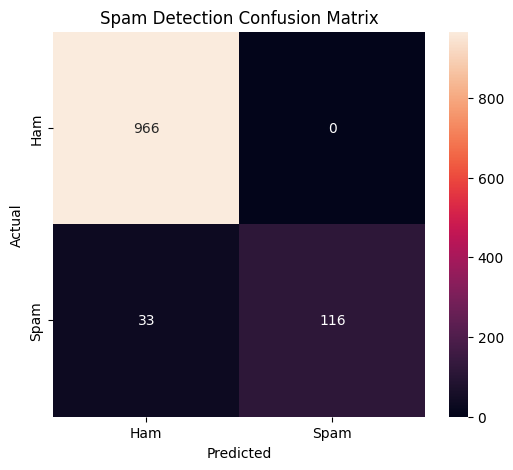

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Spam Detection Confusion Matrix")

plt.show()

In [15]:
def predict_spam(message):

    message_tfidf = vectorizer.transform([message])

    prediction = model.predict(message_tfidf)[0]

    if prediction == 1:
        return "🚨 SPAM"
    else:
        return "✅ HAM"

In [16]:
message = "Congratulations! You have won a free prize. Click now!"

print(predict_spam(message))

🚨 SPAM


In [17]:
message = "Hey, are you coming to class tomorrow?"

print(predict_spam(message))

✅ HAM


In [18]:
def predict_spam_with_probability(message):

    message_tfidf = vectorizer.transform([message])

    prediction = model.predict(message_tfidf)[0]

    probabilities = model.predict_proba(message_tfidf)[0]

    spam_probability = probabilities[1] * 100
    ham_probability = probabilities[0] * 100

    if prediction == 1:
        result = "🚨 SPAM"
    else:
        result = "✅ HAM"

    return result, ham_probability, spam_probability

In [19]:
result, ham_prob, spam_prob = predict_spam_with_probability(
    "Congratulations! You won a free lottery!"
)

print("Result:", result)
print("Ham Probability:", round(ham_prob, 2), "%")
print("Spam Probability:", round(spam_prob, 2), "%")

Result: 🚨 SPAM
Ham Probability: 38.55 %
Spam Probability: 61.45 %


In [20]:
!pip install -q gradio

In [21]:
import gradio as gr

In [22]:
def spam_detector_app(message):

    result, ham_prob, spam_prob = \
        predict_spam_with_probability(message)

    return (
        result,
        f"{ham_prob:.2f}%",
        f"{spam_prob:.2f}%"
    )

In [23]:
with gr.Blocks(title="Spam Message Detector") as app:

    gr.Markdown("# 📩 Spam Message Detection")

    gr.Markdown(
        "Enter a message to determine whether it is Spam or Ham."
    )

    message_input = gr.Textbox(
        label="Enter Message",
        placeholder="Example: Congratulations! You won a prize!"
    )

    analyze_button = gr.Button(
        "Detect Spam"
    )

    result = gr.Textbox(
        label="Prediction"
    )

    ham_probability = gr.Textbox(
        label="Ham Probability"
    )

    spam_probability = gr.Textbox(
        label="Spam Probability"
    )

    analyze_button.click(
        spam_detector_app,
        inputs=message_input,
        outputs=[
            result,
            ham_probability,
            spam_probability
        ]
    )

app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f189acf345ce583bcb.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
